<a href="https://colab.research.google.com/github/monteiro-sara/AD-RIDDLE_2024/blob/main/AD_RIDDLE_biomarkers_2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install the required packages if not already installed
# !pip install pandas numpy seaborn matplotlib scikit-learn statsmodels

# Import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from scipy import stats

In [ ]:
# Load the dataset (assuming it's a CSV, change this if it's another format)
df = pd.read_excel('/content/test_dataset_adriddle.xlsx')

# Check for missing data
print("Missing data per column:")
print(df.isnull().sum())

# Impute missing data using the mean for continuous variables
imputer = SimpleImputer(strategy='mean')
df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']] = imputer.fit_transform(df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']])

# Re-check for missing data
print("Missing data after imputation:")
print(df.isnull().sum())

Missing data per column:
participant_id            0
age                       0
sex                       0
edu_years                 1
diagnosis                 0
AD_biomarker_diagnosis    0
mmse_moca                 6
apoe4_carrier             2
csf_ab42                  1
csf_ab40                  1
csf_ab42_40_ratio         1
csf_ab42_40_abnormal      1
csf_ptau181               1
csf_ptau181_abnormal      1
csf_nfl                   1
plasma_ab42               2
plasma_ab40               2
plasma_ab42_40_ratio      2
plasma_ptau181            2
plasma_nfl                2
dtype: int64
Missing data after imputation:
participant_id            0
age                       0
sex                       0
edu_years                 1
diagnosis                 0
AD_biomarker_diagnosis    0
mmse_moca                 0
apoe4_carrier             2
csf_ab42                  1
csf_ab40                  1
csf_ab42_40_ratio         1
csf_ab42_40_abnormal      1
csf_ptau181               1
csf_pta

In [ ]:
# Detect outliers using Z-scores (values outside of 3 standard deviations are considered outliers)
z_scores = np.abs(stats.zscore(df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl']]))
outliers = np.where(z_scores > 3)

# Remove outliers based on Z-scores
df = df[(z_scores < 3).all(axis=1)]
print(f"Dataset size after removing outliers: {df.shape}")


Dataset size after removing outliers: (196, 20)


In [ ]:
# Check if there are missing values in the predictors and target
print(df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'csf_ab42_40_ratio']].isnull().sum())

# Check if there are infinite values
print(np.isfinite(df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'csf_ab42_40_ratio']]).all())

# Drop rows with NaN or infinite values in the relevant columns
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'csf_ab42_40_ratio'])

plasma_ab42          0
plasma_ab40          0
plasma_ptau181       0
plasma_nfl           0
csf_ab42_40_ratio    1
dtype: int64
plasma_ab42           True
plasma_ab40           True
plasma_ptau181        True
plasma_nfl            True
csf_ab42_40_ratio    False
dtype: bool


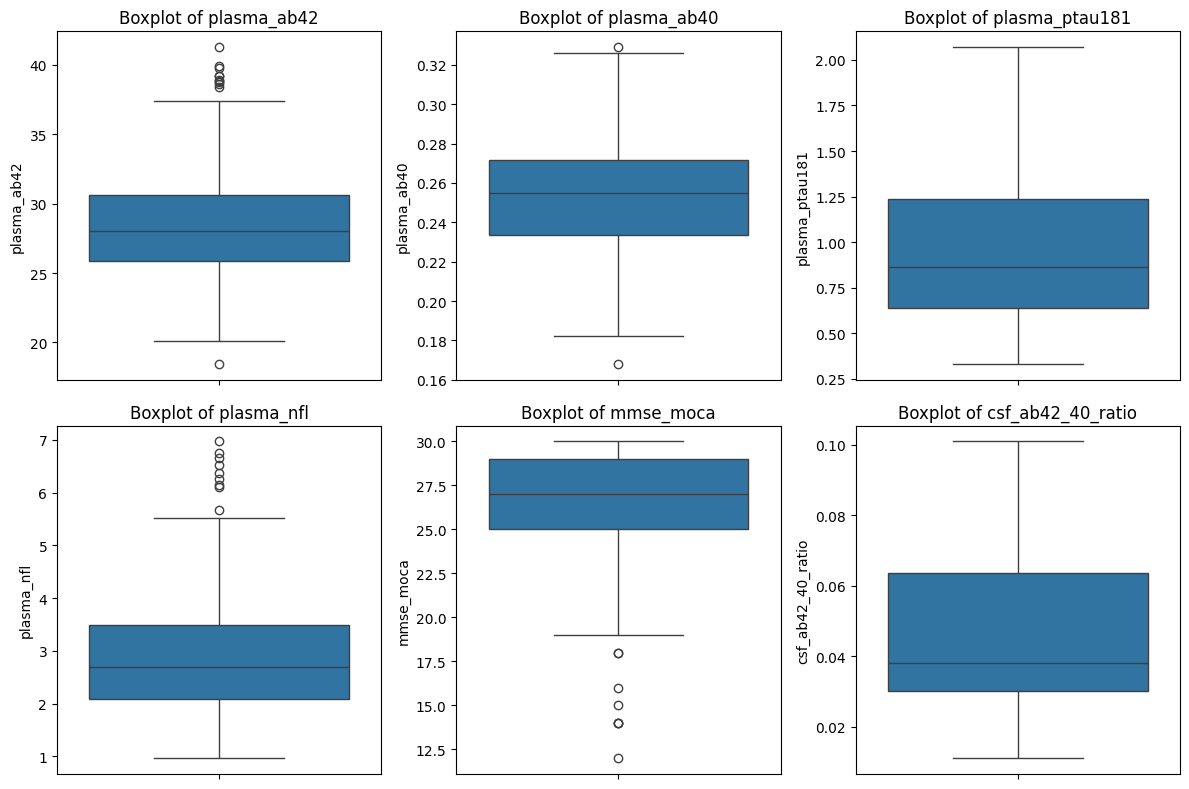

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of predictors and target for visualizing outliers
predictors = ['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']
target = 'csf_ab42_40_ratio'

# Create a boxplot for each feature
plt.figure(figsize=(12, 8))
for i, predictor in enumerate(predictors + [target]):
    plt.subplot(2, 3, i + 1)  # Create subplots for each variable
    sns.boxplot(data=df[predictor])
    plt.title(f'Boxplot of {predictor}')
    plt.tight_layout()
plt.show()


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Ensure scikit-learn is up to date
!pip install --upgrade scikit-learn

#Import plot_partial_dependence
from sklearn.inspection import plot_partial_dependence #This function is available in scikit-learn 0.24.1 and above


# Load your dataset (update the path if needed)
# df = pd.read_csv('your_dataset.csv')

# Step 1: Handle Missing Data
# Impute missing values with the mean for continuous variables
imputer = SimpleImputer(strategy='mean')
df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']] = imputer.fit_transform(
    df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']])

# Step 2: Define predictors and target variable
X = df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']]
y = df['csf_ab42_40_ratio']

# Step 3: Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Feature Scaling (Optional for Random Forest, but can be done for consistency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Initialize and train the Random Forest Regressor
# You can tune n_estimators and other hyperparameters as needed
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Step 6: Make predictions on the test set
y_pred = rf.predict(X_test_scaled)

# Step 7: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Step 8: Feature Importance (to understand the relevance of each predictor)
importances = rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest')
plt.show()

# Predicted vs Actual plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)  # Diagonal line
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual CSF Aβ42/40 Ratio')
plt.ylabel('Predicted CSF Aβ42/40 Ratio')
plt.show()

# Partial Depend

       plasma_ab42  plasma_ab40  plasma_ptau181  plasma_nfl   mmse_moca  \
count   195.000000   195.000000      195.000000  195.000000  195.000000   
mean     28.514770     0.253757        0.962254    2.962407   26.419243   
std       4.373297     0.028055        0.415473    1.282129    3.734927   
min      18.450000     0.168000        0.331000    0.961000   12.000000   
25%      25.845000     0.233500        0.640500    2.080000   25.000000   
50%      28.060000     0.255000        0.863000    2.690000   27.000000   
75%      30.620000     0.271500        1.235000    3.485000   29.000000   
max      41.260000     0.329000        2.070000    6.970000   30.000000   

       csf_ab42_40_ratio  
count         195.000000  
mean            0.044836  
std             0.019310  
min             0.011000  
25%             0.030000  
50%             0.038000  
75%             0.063500  
max             0.101000  


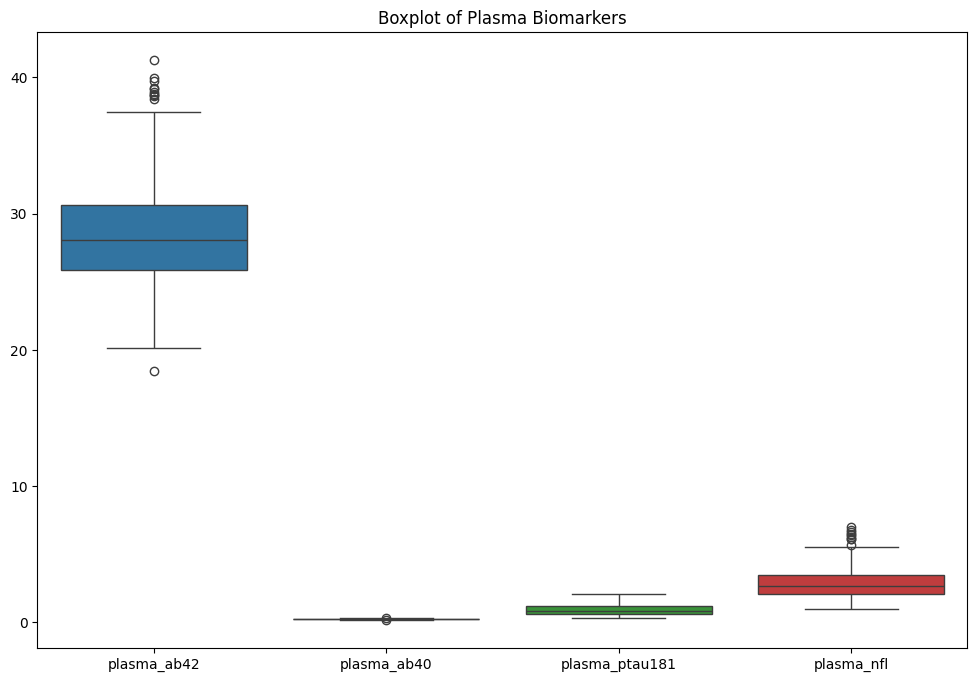

In [ ]:
# Descriptive statistics for continuous variables
print(df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca', 'csf_ab42_40_ratio']].describe())

# Boxplot to visualize the distribution of biomarkers
plt.figure(figsize=(12, 8))
sns.boxplot(data=df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl']])
plt.title('Boxplot of Plasma Biomarkers')
plt.show()


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Ensure scikit-learn is up to date
!pip install --upgrade scikit-learn

#Import plot_partial_dependence
from sklearn.inspection import plot_partial_dependence #This function is available in scikit-learn 0.24.1 and above


# Load your dataset (update the path if needed)
# df = pd.read_csv('your_dataset.csv')

# Step 1: Handle Missing Data
# Impute missing values with the mean for continuous variables
imputer = SimpleImputer(strategy='mean')
df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']] = imputer.fit_transform(
    df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']])

# Step 2: Define predictors and target variable
X = df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']]
y = df['csf_ab42_40_ratio']

# Step 3: Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Feature Scaling (Optional for Random Forest, but can be done for consistency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Initialize and train the Random Forest Regressor
# You can tune n_estimators and other hyperparameters as needed
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Step 6: Make predictions on the test set
y_pred = rf.predict(X_test_scaled)

# Step 7: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Step 8: Feature Importance (to understand the relevance of each predictor)
importances = rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest')
plt.show()

# Predicted vs Actual plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)  # Diagonal line
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual CSF Aβ42/40 Ratio')
plt.ylabel('Predicted CSF Aβ42/40 Ratio')
plt.show()

# Partial Depend

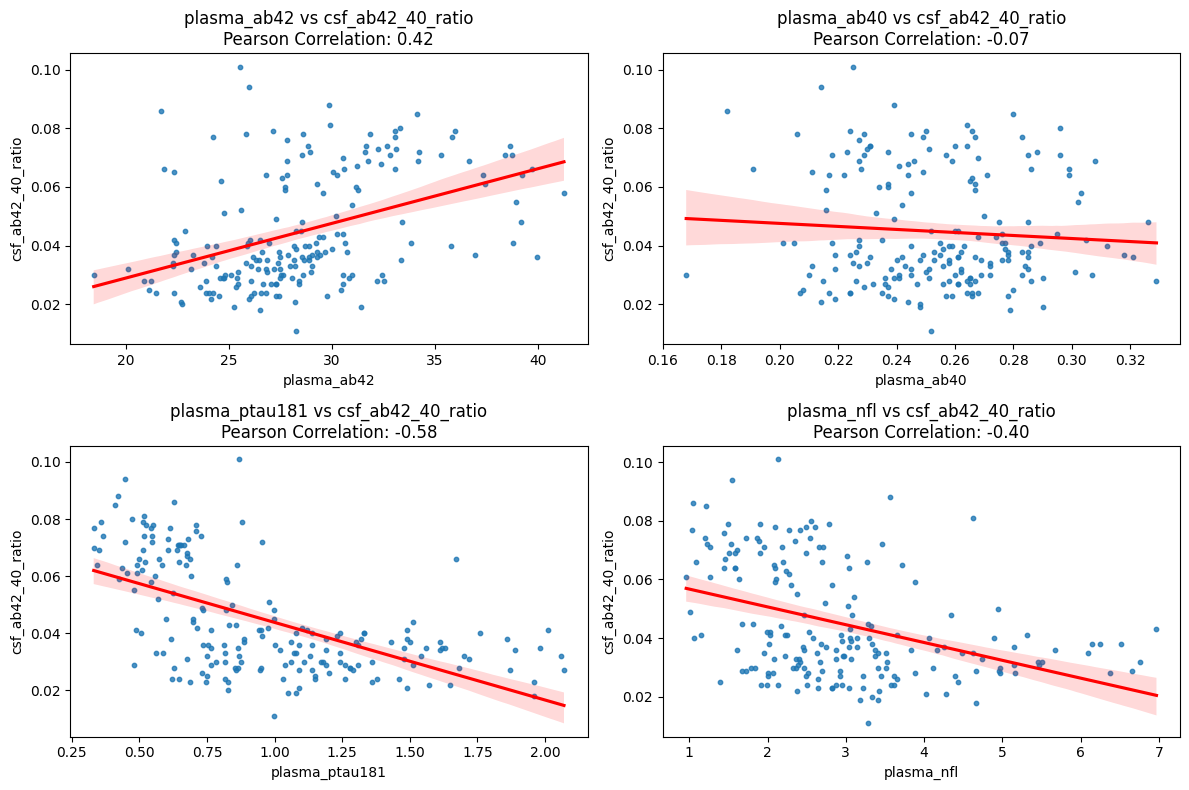

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Set up the figure size and grid
plt.figure(figsize=(12, 8))

# List of predictors
predictors = ['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl']
target = 'csf_ab42_40_ratio'

# Create scatter plots with trend lines and correlation values
for i, predictor in enumerate(predictors):
    plt.subplot(2, 2, i + 1)

    # Scatter plot with trend line
    sns.regplot(x=predictor, y=target, data=df, scatter_kws={'s':10}, line_kws={'color':'red'})

    # Calculate Pearson correlation coefficient
    corr, _ = pearsonr(df[predictor], df[target])

    # Set plot title with the correlation value
    plt.title(f'{predictor} vs {target}\nPearson Correlation: {corr:.2f}')

    # Adjust layout
    plt.tight_layout()

plt.show()


Mean Squared Error: 0.00013255626779661012
R-squared: 0.6198543703349757


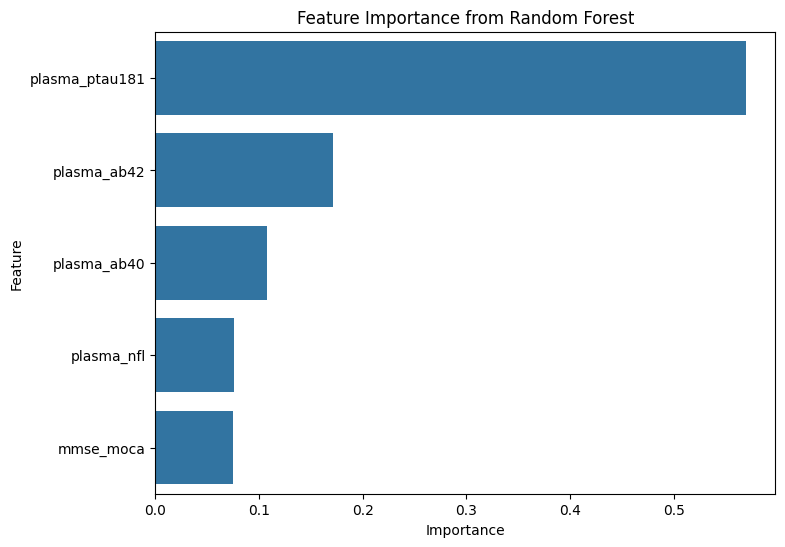

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Load your dataset (update the path if needed)
# df = pd.read_csv('your_dataset.csv')

# Step 1: Handle Missing Data
# Impute missing values with the mean for continuous variables
imputer = SimpleImputer(strategy='mean')
df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']] = imputer.fit_transform(
    df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']])

# Step 2: Define predictors and target variable
X = df[['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']]
y = df['csf_ab42_40_ratio']

# Step 3: Split the data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 4: Feature Scaling (Optional for Random Forest, but can be done for consistency)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Initialize and train the Random Forest Regressor
# You can tune n_estimators and other hyperparameters as needed
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Step 6: Make predictions on the test set
y_pred = rf.predict(X_test_scaled)

# Step 7: Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# Step 8: Feature Importance (to understand the relevance of each predictor)
importances = rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Plot the feature importance
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance from Random Forest')
plt.show()


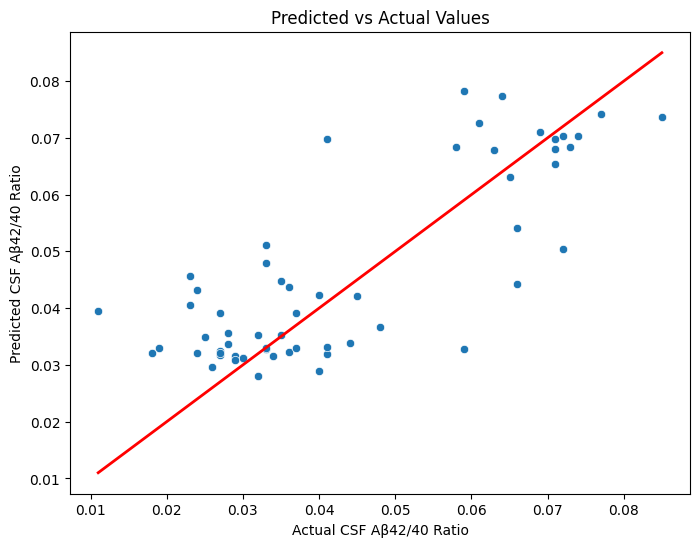

In [ ]:
# Predicted vs Actual plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', lw=2)  # Diagonal line
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual CSF Aβ42/40 Ratio')
plt.ylabel('Predicted CSF Aβ42/40 Ratio')
plt.show()


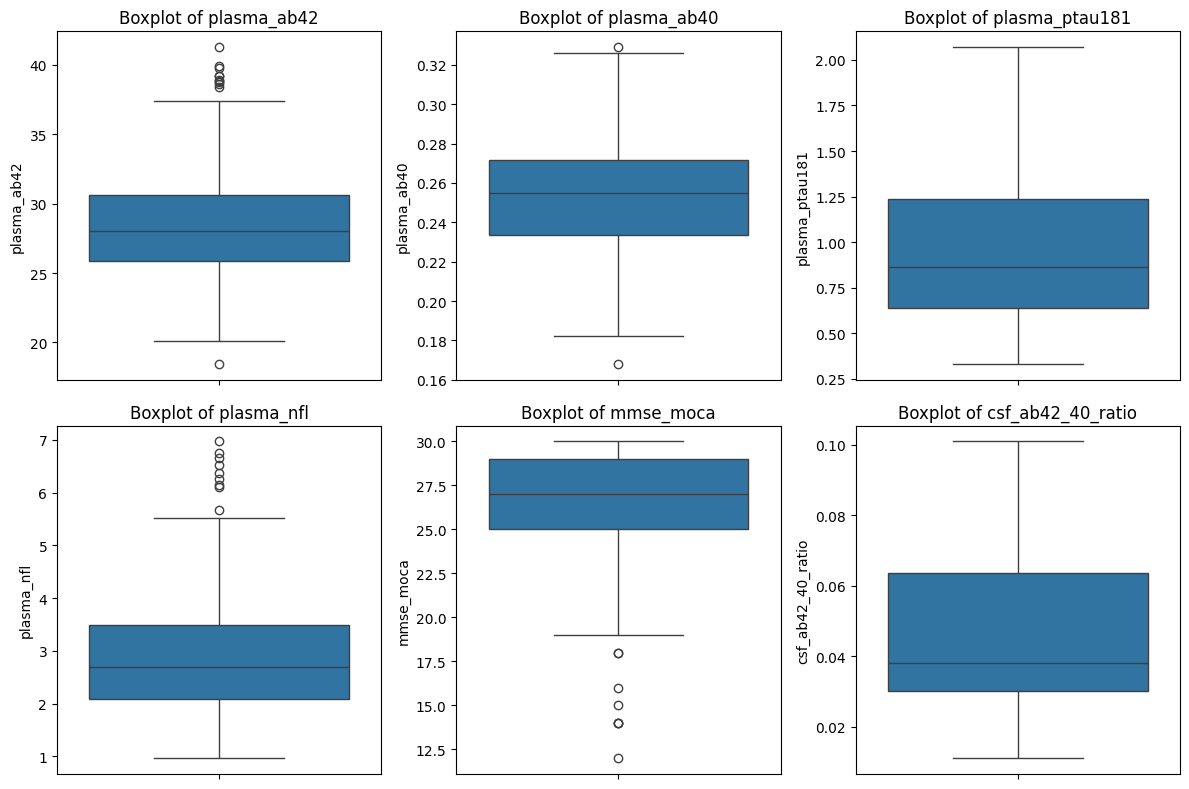

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of predictors and target for visualizing outliers
predictors = ['plasma_ab42', 'plasma_ab40', 'plasma_ptau181', 'plasma_nfl', 'mmse_moca']
target = 'csf_ab42_40_ratio'

# Create a boxplot for each feature
plt.figure(figsize=(12, 8))
for i, predictor in enumerate(predictors + [target]):
    plt.subplot(2, 3, i + 1)  # Create subplots for each variable
    sns.boxplot(data=df[predictor])
    plt.title(f'Boxplot of {predictor}')
    plt.tight_layout()
plt.show()


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the Random Forest model
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the grid search model
grid_search.fit(X_train_scaled, y_train)

# Best parameters found by GridSearchCV
print("Best parameters found: ", grid_search.best_params_)

# Use the best model for predictions
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

# Evaluate the tuned model
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
print(f"Tuned Model Mean Squared Error: {mse_best}")
print(f"Tuned Model R-squared: {r2_best}")


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters found:  {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Model Mean Squared Error: 0.00014591735094042374
Tuned Model R-squared: 0.5815373789988507


In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize the Random Forest model
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the grid search model
grid_search.fit(X_train_scaled, y_train)

# Best parameters found by GridSearchCV
print("Best parameters found: ", grid_search.best_params_)

# Use the best model for predictions
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

# Evaluate the tuned model
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)
print(f"Tuned Model Mean Squared Error: {mse_best}")
print(f"Tuned Model R-squared: {r2_best}")


Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best parameters found:  {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Tuned Model Mean Squared Error: 0.0001950384003579243
Tuned Model R-squared: 0.43987097890357496


In [ ]:
import pandas as pd

# Create a dictionary to hold model performance metrics
summary_dict = {
    'Model': ['Initial Random Forest', 'Tuned Random Forest'],
    'Mean Squared Error': [mse, mse_best],
    'R-squared': [r2, r2_best]
}

# Convert the dictionary to a pandas DataFrame
summary_df = pd.DataFrame(summary_dict)

# Display the summary table
print("Model Performance Summary")
print(summary_df)

# To display in a more aesthetic way in a Jupyter Notebook or Colab, you can use:
summary_df.style.set_caption("Model Performance Summary").format({'Mean Squared Error': "{:.4f}", 'R-squared': "{:.4f}"})


In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette="viridis")
plt.title('Feature Importance in Predicting CSF Aβ42/40 Ratio', fontsize=16)
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Feature', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred_best, scatter_kws={'s':30}, line_kws={'color':'red'})
plt.title('Predicted vs Actual CSF Aβ42/40 Ratio (Tuned Random Forest)', fontsize=16)
plt.xlabel('Actual CSF Aβ42/40 Ratio', fontsize=14)
plt.ylabel('Predicted CSF Aβ42/40 Ratio', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='blue', lw=2, ls='--')  # Diagonal reference line
plt.tight_layout()
plt.show()


In [ ]:
residuals = y_test - y_pred_best

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_best, y=residuals)
plt.axhline(y=0, color='red', lw=2)
plt.title('Residuals vs Predicted Values (Tuned Random Forest)', fontsize=16)
plt.xlabel('Predicted CSF Aβ42/40 Ratio', fontsize=14)
plt.ylabel('Residuals', fontsize=14)
plt.tight_layout()
plt.show()
